<a href="https://colab.research.google.com/github/MapacheGangStore/Limpieza-Datos-Cancer/blob/main/LimpiezaDeDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 1. Cargar el dataset original
# Nota: Debes subir el archivo Breast_Cancer.csv a la carpeta de archivos de Colab antes de correr esto.
df = pd.read_csv("Breast_Cancer.csv")

print("--- 1. ESTADO ORIGINAL ---")
print(f"Total de registros: {df.shape[0]} filas y {df.shape[1]} columnas.")

# --- PASO A: Renombrar y estandarizar columnas ---
# Corregimos errores tipográficos y quitamos espacios
df.rename(columns={
    'Marital Status': 'Marital_Status',
    'T Stage ': 'T_Stage',
    'N Stage': 'N_Stage',
    '6th Stage': '6th_Stage',
    'Tumor Size': 'Tumor_Size',
    'Estrogen Status': 'Estrogen_Status',
    'Progesterone Status': 'Progesterone_Status',
    'Regional Node Examined': 'Regional_Node_Examined',
    'Reginol Node Positive': 'Regional_Node_Positive', # Aquí estaba el error
    'Survival Months': 'Survival_Months'
}, inplace=True)

# Limpieza de espacios accidentales
df.columns = df.columns.str.strip()

print("\n--- Columnas procesadas correctamente ---")
print(df.columns.tolist())

--- 1. ESTADO ORIGINAL ---
Total de registros: 4024 filas y 16 columnas.

--- Columnas procesadas correctamente ---
['Age', 'Race', 'Marital_Status', 'T_Stage', 'N_Stage', '6th_Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor_Size', 'Estrogen_Status', 'Progesterone_Status', 'Regional_Node_Examined', 'Regional_Node_Positive', 'Survival_Months', 'Status']


In [2]:
# --- PASO B: Búsqueda de Valores Nulos (Missing Values) ---
print("\n--- 2. VALORES NULOS ---")
nulos = df.isnull().sum().sum()
print(f"Total de valores nulos o vacíos encontrados: {nulos}")
if nulos > 0:
    df = df.dropna()
    print("Valores nulos eliminados.")

# --- PASO C: Identificación y eliminación de Duplicados ---
print("\n--- 3. DATOS DUPLICADOS ---")
duplicados = df.duplicated().sum()
print(f"Filas exactamente duplicadas encontradas: {duplicados}")
# Eliminamos los duplicados manteniendo solo la primera aparición
df = df.drop_duplicates()
print(f"Registros después de eliminar duplicados: {df.shape[0]}")

# --- PASO D: Tratamiento de Valores Atípicos (Outliers) ---
# Usamos el método IQR (Rango Intercuartílico) para el tamaño del tumor
Q1 = df['Tumor_Size'].quantile(0.25)
Q3 = df['Tumor_Size'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print("\n--- 4. VALORES ATÍPICOS ---")
outliers_tumor = df[df['Tumor_Size'] > limite_superior]
print(f"Pacientes con tumores atípicamente grandes (> {limite_superior:.2f} mm): {outliers_tumor.shape[0]}")
# Nota: No los borramos por ser datos médicos reales, pero los dejamos identificados.

# --- PASO E: Exportación del Dataset Limpio ---
# Este archivo es el que usarán Leo y Roxana para sus gráficas
df.to_csv("Breast_Cancer_Limpio.csv", index=False)
print("\n--- 5. ESTADO FINAL ---")
print(f"Dataset listo y guardado como 'Breast_Cancer_Limpio.csv'. Total: {df.shape[0]} filas.")


--- 2. VALORES NULOS ---
Total de valores nulos o vacíos encontrados: 0

--- 3. DATOS DUPLICADOS ---
Filas exactamente duplicadas encontradas: 1
Registros después de eliminar duplicados: 4023

--- 4. VALORES ATÍPICOS ---
Pacientes con tumores atípicamente grandes (> 71.00 mm): 222

--- 5. ESTADO FINAL ---
Dataset listo y guardado como 'Breast_Cancer_Limpio.csv'. Total: 4023 filas.


--- 6. ANÁLISIS DE DISTRIBUCIÓN Y SUPERVIVENCIA ---


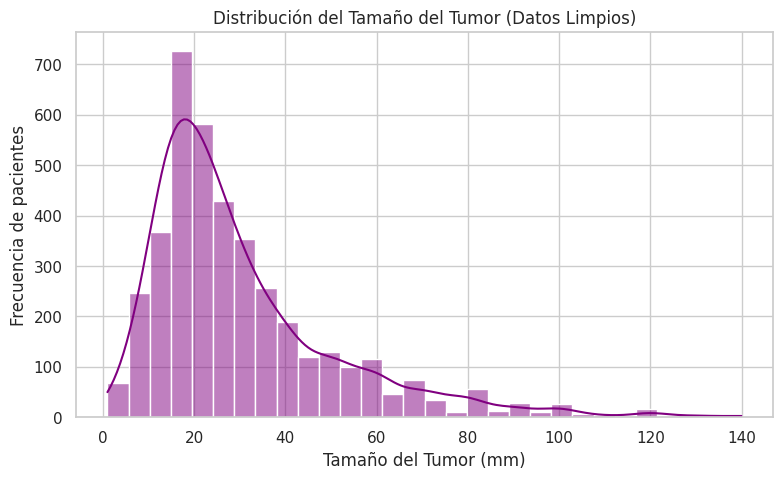

/tmp/ipykernel_7011/3085459644.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='Survival_Months', data=df_limpio, palette='Set2')


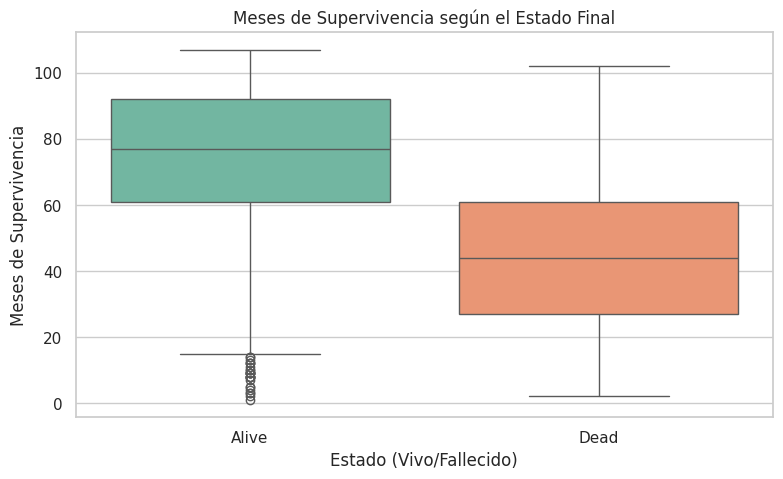

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset que Eduardo dejó listo
df_limpio = pd.read_csv("Breast_Cancer_Limpio.csv")

# Configurar el estilo visual para el equipo
sns.set_theme(style="whitegrid")

print("--- 6. ANÁLISIS DE DISTRIBUCIÓN Y SUPERVIVENCIA ---")

# ==========================================
# GRÁFICA 1: Histograma del Tamaño del Tumor
# ==========================================
plt.figure(figsize=(9, 5))
sns.histplot(df_limpio['Tumor_Size'], bins=30, kde=True, color='purple')
plt.title('Distribución del Tamaño del Tumor (Datos Limpios)')
plt.xlabel('Tamaño del Tumor (mm)')
plt.ylabel('Frecuencia de pacientes')
plt.show()

# ==========================================
# GRÁFICA 2: Boxplot (Supervivencia vs Estado)
# ==========================================
plt.figure(figsize=(9, 5))
sns.boxplot(x='Status', y='Survival_Months', data=df_limpio, palette='Set2')
plt.title('Meses de Supervivencia según el Estado Final')
plt.xlabel('Estado (Vivo/Fallecido)')
plt.ylabel('Meses de Supervivencia')
plt.show()